# 02 - Causal Feature Selection, Causal Graph & Predictive Modeling

This notebook is the causal-inference core of the project, and follows Judea Pearl's three-stage framework:

1. **Statistical screening** (association only, rung 1 of the Ladder of Causation) - narrow 30 raw features to a manageable shortlist.
2. **A causal graph** (rung 2, *intervention*) - encode domain knowledge about tumor cytology as a DAG, then use `DoWhy` to identify a valid backdoor adjustment set and estimate each treatment's causal effect on diagnosis, stress-tested with refutation checks.
3. **Predictive modeling + SHAP** - train several classifiers on the causally-motivated feature set and explain their predictions.

All logic lives in the `ml` package; this notebook narrates *why* each step exists and inspects the results, rather than re-implementing them.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from ml.config import TARGET
from ml.data import load_dataset, clean_dataset
from ml.features import compute_feature_scores, select_top_features
from ml.causal_graph import build_causal_graph, draw_causal_graph, estimate_causal_effects, results_to_frame
from ml.modeling import split_data, train_and_evaluate, best_model_name
from ml.interpret import compute_shap_importance

if sys.platform == 'win32':
    try:
        sys.stdout.reconfigure(encoding='utf-8')
    except Exception:
        pass

df = clean_dataset(load_dataset())
X, y = df.drop(columns=[TARGET]), df[TARGET]
X_train, X_test, y_train, y_test = split_data(X, y)
df.shape

(569, 31)

## 1. Statistical feature selection

**Important framing:** none of ANOVA F-scores, mutual information, Random Forest importances, or logistic-regression coefficients establish causality on their own - they measure statistical *association* (correlation, non-linear dependency, predictive usefulness). We combine four such signals into a single normalized `Causal_Score` purely as a **screening heuristic** to shrink 30 features down to 15 before doing the actual causal analysis below.

In [2]:
scaler = StandardScaler().fit(X_train)
feature_scores = compute_feature_scores(X_train, y_train, scaler.transform(X_train))
feature_scores[['Causal_Score', 'F_Score', 'MI_Score', 'RF_Importance']].head(15)

,Causal_Score,F_Score,MI_Score,RF_Importance
perimeter_worst,0.861900,717.246487,0.454559,0.147912
area_worst,0.799928,522.188947,0.453342,0.132269
concave points_worst,0.787073,733.724933,0.432900,0.110114
concave points_mean,0.784664,684.526845,0.445956,0.088200
radius_worst,0.780334,692.861395,0.461221,0.085116
perimeter_mean,0.561855,548.413236,0.409301,0.060465
radius_mean,0.531262,511.274848,0.373251,0.060554
concavity_mean,0.530061,397.592082,0.354085,0.044091
area_mean,0.496336,444.857518,0.374696,0.044701
concavity_worst,0.477776,319.507776,0.299396,0.032828


In [3]:
top_features = select_top_features(feature_scores)
print(f'Selected {len(top_features)} features:')
top_features

Selected 15 features:


['perimeter_worst',
 'area_worst',
 'concave points_worst',
 'concave points_mean',
 'radius_worst',
 'perimeter_mean',
 'radius_mean',
 'concavity_mean',
 'area_mean',
 'concavity_worst',
 'area_se',
 'radius_se',
 'texture_worst',
 'perimeter_se',
 'compactness_mean']

## 2. The causal graph (Pearl's framework)

We now step off the purely statistical path. The DAG below encodes **domain knowledge about tumor cytology**, not anything learned from the data:

- `radius` mechanically determines `perimeter` and `area` (perimeter ~ 2*pi*r, area ~ pi*r^2) - radius is their common cause.
- `concavity` (severity of concave regions of the cell contour) drives `concave points` (count of concave regions).
- `*_mean` (the average cell in a sample) and `*_worst` (the most extreme cell) are both downstream of the same underlying tumor severity, modeled as `*_mean -> *_worst`.
- The four "worst" shape/contour measurements are modeled as direct causes of `diagnosis`, since pathologists diagnose malignancy from the most abnormal cells in a sample, not the average ones.

See `ml/causal_graph.py` for the full edge list and rationale.

11 nodes, 16 edges


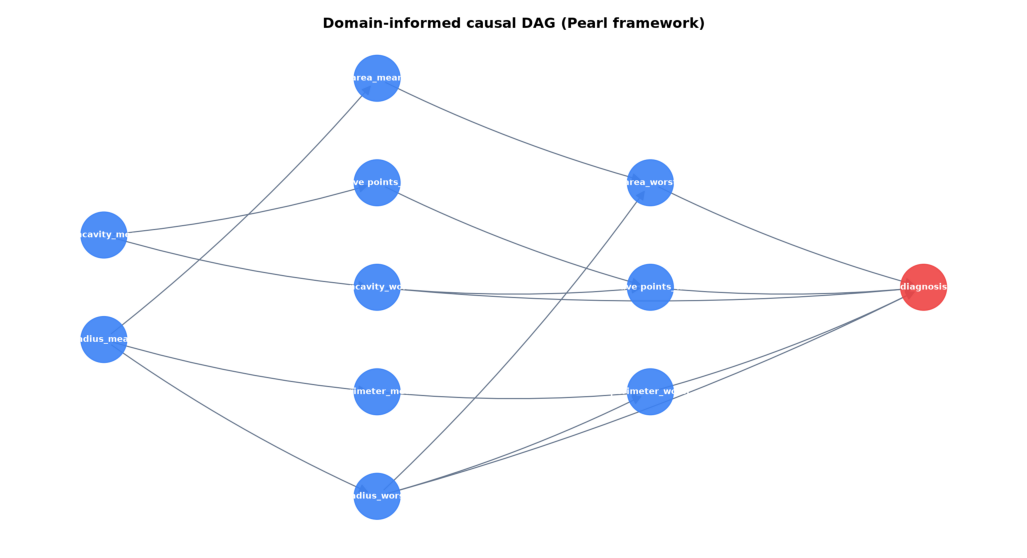

In [4]:
dag = build_causal_graph()
draw_causal_graph(dag, '../outputs/figures/causal_graph.png')
print(f'{dag.number_of_nodes()} nodes, {dag.number_of_edges()} edges')
plt.figure(figsize=(13, 7))
img = plt.imread('../outputs/figures/causal_graph.png')
plt.imshow(img)
plt.axis('off')
plt.show()

### Identifying and estimating causal effects

For each "worst" feature that the DAG marks as a direct cause of `diagnosis`, `DoWhy`:

1. **Identifies** a valid backdoor adjustment set from the graph structure alone (Pearl's backdoor criterion) - the other parents of `diagnosis` that must be controlled for to block confounding paths.
2. **Estimates** the adjusted average treatment effect (ATE) with a linear outcome-regression estimator, on standardized features so effect sizes are comparable across treatments.
3. **Refutes**: re-estimates after (a) adding a random common cause, which a genuinely causal estimate should be insensitive to, and (b) permuting (placebo-ing) the treatment, which a genuinely causal estimate should collapse towards zero under.

This is the step that actually distinguishes this project from a plain feature-importance exercise: it makes the causal assumptions explicit (the graph) and checks whether the resulting effect estimate is fragile or robust.

In [5]:
effects = estimate_causal_effects(df, dag)
effects_frame = results_to_frame(effects)
effects_frame

C:\Users\Admin\Desktop\projects\Causality\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,treatment,standardized_ATE,refute_random_common_cause,refute_placebo,adjustment_set,robust_to_placebo
2,area_worst,0.839560,0.838719,-0.003686,"area_mean, concave points_mean, concave points...",True
0,radius_worst,0.684396,0.687329,-0.002384,"area_mean, concave points_mean, concave points...",True
1,perimeter_worst,0.593235,0.593061,-0.003142,"area_mean, area_worst, concave points_mean, co...",True
4,concave points_worst,0.407409,0.407365,-0.002501,"area_mean, area_worst, concave points_mean, co...",True
3,concavity_worst,0.089075,0.088760,0.004801,"area_mean, area_worst, concave points_mean, co...",True


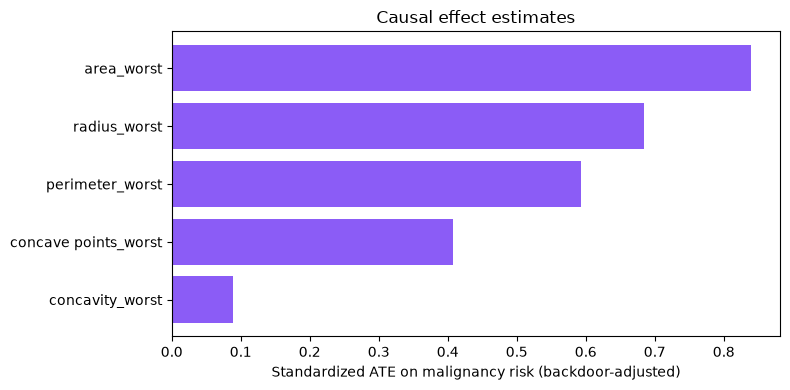

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(effects_frame['treatment'], effects_frame['standardized_ATE'], color='#8b5cf6')
ax.set_xlabel('Standardized ATE on malignancy risk (backdoor-adjusted)')
ax.set_title('Causal effect estimates')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

A treatment is flagged `robust_to_placebo=True` when its placebo (permuted-treatment) effect is less than half the magnitude of the original estimate - i.e. the effect meaningfully depends on the real treatment values, not just on model flexibility. Features whose causal effect does **not** survive this check should be trusted less than their statistical (association-only) ranking in step 1 might suggest.

## 3. Predictive modeling

With the shortlist from step 1, we train four classifiers and compare them on held-out data using accuracy, precision, recall, F1 and ROC-AUC (with 5-fold stratified cross-validation for the ROC-AUC estimate).

In [7]:
results, top_scaler = train_and_evaluate(X_train[top_features], X_test[top_features], y_train, y_test)
comparison = pd.DataFrame([r.as_dict() for r in results.values()]).set_index('Model')
comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
Model,,,,,,,
Logistic Regression,0.973684,0.97561,0.952381,0.963855,0.996693,0.995253,0.003286
Random Forest,0.973684,1.00000,0.928571,0.962963,0.995701,0.988390,0.007131
Gradient Boosting,0.956140,1.00000,0.880952,0.936709,0.998016,0.992157,0.005143
SVM,0.982456,1.00000,0.952381,0.975610,0.995701,0.994737,0.005039


Best model: Gradient Boosting (ROC-AUC = 0.9980)


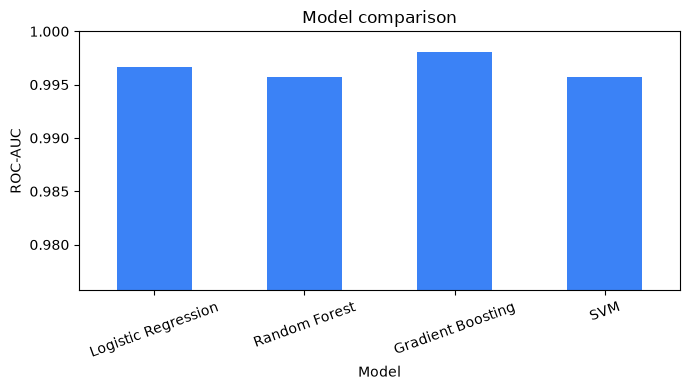

In [8]:
best_name = best_model_name(results)
print(f'Best model: {best_name} (ROC-AUC = {results[best_name].roc_auc:.4f})')

fig, ax = plt.subplots(figsize=(7, 4))
comparison['ROC-AUC'].plot(kind='bar', ax=ax, color='#3b82f6')
ax.set_ylim(comparison['ROC-AUC'].min() - 0.02, 1.0)
ax.set_ylabel('ROC-AUC')
ax.set_title('Model comparison')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. SHAP interpretation

SHAP explains *this specific model's* predictions - it is a post-hoc, correlational explanation of learned behavior, which is a different (and weaker) claim than the backdoor-adjusted causal effects estimated in step 2. We include both deliberately: SHAP for "what is the Random Forest actually using", DoWhy for "what do we believe is causal, and how confident are we".

In [9]:
shap_importance, shap_values = compute_shap_importance(results['Random Forest'].model, X_test[top_features])
shap_importance.head(10)

,Feature,SHAP_Importance
4,radius_worst,0.067260
2,concave points_worst,0.064067
0,perimeter_worst,0.063858
3,concave points_mean,0.057120
1,area_worst,0.054511
8,area_mean,0.027204
9,concavity_worst,0.025359
12,texture_worst,0.024355
7,concavity_mean,0.022338
10,area_se,0.018118


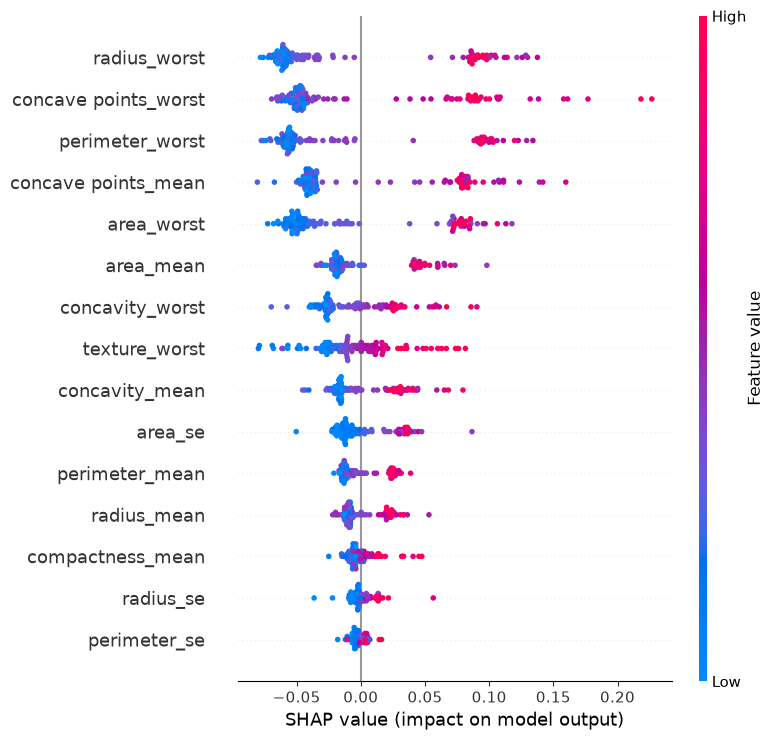

In [10]:
import shap
shap.summary_plot(shap_values, X_test[top_features], show=False)
plt.tight_layout()
plt.show()

## 5. Conclusion

- Statistical screening and SHAP broadly agree on *which* features matter for prediction: the "worst" concavity, concave-point-count, perimeter and area measurements dominate.
- The DoWhy backdoor-adjusted estimates in step 2 add something orthogonal: an explicit, falsifiable causal model, with refutation tests that separate effects that survive scrutiny from ones that may just be artifacts of confounding or model flexibility.
- The full pipeline (feature selection -> causal graph -> modeling -> SHAP -> saved artifacts) is reproducible end-to-end with a single command: `python -m ml.pipeline`.